In [4]:
import pandas as pd
X_train = pd.read_csv("Temp data/X_train.csv", sep=",")
X_test = pd.read_csv("Temp data/X_test.csv", sep=",")
y_train = pd.read_csv("Temp data/y_train.csv", sep=",")
y_test = pd.read_csv("Temp data/y_test.csv", sep=",")

## Preprocessing

In [1]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    KBinsDiscretizer,
    OneHotEncoder,
    StandardScaler,
)


preprocessor1 = ColumnTransformer([
    ("onehot_cat", OneHotEncoder(sparse_output=False, categories='auto', drop='first'),
     ["draw_size", "surface", "tourney_level", "best_of"])
     ,("diff_standardize", StandardScaler(),['age_diff','rank_diff','height_diff','Rolling_WLR_diff','Rolling_SVP_diff','Rolling_BPS_diff'])

], remainder="drop")


## Gradient-boosting model

In [7]:

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


gbm = Pipeline(
    [
        ("preprocessor",preprocessor1),
        ("regressor", HistGradientBoostingClassifier(learning_rate = 0.1, max_iter = 200, min_samples_leaf = 200))
    ]
)
gbm.fit(X_train,y_train)
gbm_pred = gbm.predict_proba(X_test)[:,1]



c:\Users\Alex\anaconda3\envs\tf\lib\site-packages\sklearn\utils\validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[[1102  580]
 [ 643 1075]]


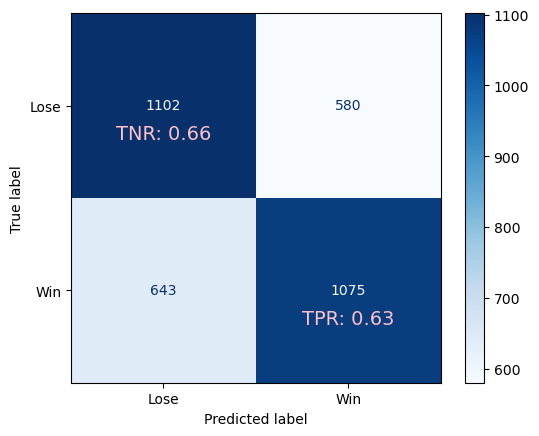

In [8]:
import matplotlib.pyplot as plt
gbm_pred_label = [1 if val >= 0.5 else 0 for val in gbm_pred]
gbm_confusion = confusion_matrix(y_test,gbm_pred_label)
print(gbm_confusion)
# Calculate true positive rate (sensitivity)
TPR = gbm_confusion[1, 1] / (gbm_confusion[1, 1] + gbm_confusion[1, 0])
TNR = gbm_confusion[0, 0] / (gbm_confusion[0, 0] + gbm_confusion[0, 1])
Accuracy = (gbm_confusion[1, 1] +gbm_confusion[0, 0]) /(gbm_confusion[0, 0] + gbm_confusion[1, 0]+gbm_confusion[0, 1] + gbm_confusion[1, 1])
# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=gbm_confusion, display_labels=['Lose', 'Win'])
disp.plot(cmap='Blues', values_format='d')  # Adjust the colormap and format as needed

# Add text for true positive rate
plt.text(1, 1.1, f'TPR: {TPR:.2f}', color='pink', fontsize=14, va='top', ha='center')
plt.text(0, 0.1, f'TNR: {TNR:.2f}', color='pink', fontsize=14, va='top', ha='center')

# Show the plot
plt.show()

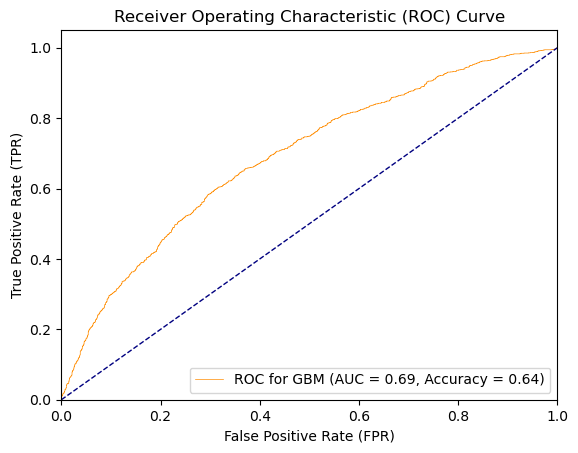

In [9]:
from sklearn.metrics import roc_curve, roc_auc_score, auc
from sklearn.metrics import mean_squared_error
fpr1, tpr1, thresholds = roc_curve(y_test, gbm_pred)
roc_auc1 = auc(fpr1, tpr1)
plt.plot(fpr1, tpr1, color='darkorange', lw=.5, label=f'ROC for GBM (AUC = {roc_auc1:.2f}, Accuracy = {Accuracy:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.savefig('ROC.png')
plt.show()

The Accuracy metric measures the overall accuracy of our model, i.e. the number of correct classifications out of the total number of classifications, and can be extracted from the confusion matrix. 
\begin{equation*}
\text{Accuracy} = \dfrac{TP+TN}{P+N}
\end{equation*}.

In [17]:
print("Misclassification error for GBM:",1-Accuracy)

Misclassification error for GBM: 0.3597058823529412


### Hyper-parameter tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'regressor__learning_rate': [0.01, 0.1, 0.2],
    'regressor__max_iter': [50, 100, 200,300],
    'regressor__min_samples_leaf': [20, 50, 200],
}
# Perform grid search with cross-validation
grid_search = GridSearchCV(gbm, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Print the best hyperparameters
print("Best Hyperparameters:", grid_search.best_params_)

# Evaluate the model on the test set using the best hyperparameters
best_gbm = grid_search.best_estimator_
accuracy = best_gbm.score(X_test, y_test)
print("Test Accuracy:", accuracy)